In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score,average_precision_score,confusion_matrix,roc_curve,ConfusionMatrixDisplay
pd.set_option('display.max_columns', None)

In [15]:
subject_info = pd.read_csv('/Users/eric/repos/aud/data/subject_info.csv')
subject_info.head()

,subid,mema_count,last_morning_ema_day,first_morning_ema_day
0,1,65,89,0
1,2,78,84,0
2,3,87,89,0
3,5,90,91,0
4,6,81,86,0


In [22]:
# 164409 is complete dataset with clipping occurring before averaging
# 175905 runs MLE, MARSS (with longer runs), MAP_mle, and MAP_marss
import_path = "/Users/eric/repos/aud/analysis/imports/175905"
files = [file for file in os.listdir(import_path) if file.endswith(".csv")]
df_list = []
for file in files:
    iter_df = pd.read_csv(os.path.join(import_path,file))
    if iter_df.shape[1] != 23:
        pass#print("wtf")
    df_list.append(iter_df)

#print(len(df_list))
df = pd.concat(df_list,ignore_index=True)
print(df.shape)
df.head()



(49991, 67)


,fit_type,subid,train_horizon,converged,fit_error,pred_0,act_0,w0_pred,w1_pred,w2_pred,w3_pred,w4_pred,w5_pred,w6_pred,w7_pred,w0_act,w1_act,w2_act,w3_act,w4_act,w5_act,w6_act,w7_act,z11,z21,z31,z41,z51,z61,z71,z81,z91,z101,z12,z22,z32,z42,z52,z62,z72,z82,z92,z102,a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,r1,r2,r3,r4,r5,r6,r7,r8,r9,b11,b22,u1,u2,Unnamed: 0
0,MAP_mle,268.0,2.0,True,0,0.063842,0.0,6.389168e-02,9.080365e-02,9.220495e-02,9.220661e-02,9.220661e-02,9.220661e-02,9.220661e-02,9.220661e-02,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.014967,0.013162,0.036276,-0.038580,-0.039429,-0.075159,0.042442,0.027279,0.020038,0.008342,0.015552,0.013596,0.011153,0.025875,0.006335,0.023950,-0.003042,-0.003881,0.005049,0.007160,0.024216,0.020590,0.056890,0.359768,0.837521,0.846700,0.365641,0.736433,0.130795,0.066563,0.000972,0.000896,0.002645,0.002281,0.001823,0.006488,0.001716,0.001358,0.001069,0.200072,1.0,4.886329,-5.918185,NaN
1,MAP_mle,268.0,3.0,True,0,-0.034386,0.0,9.999779e-13,1.999956e-12,2.999934e-12,3.999912e-12,4.999889e-12,5.999867e-12,6.999845e-12,7.999823e-12,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.000245,0.000226,0.022832,-0.066640,-0.033703,-0.082955,0.053424,0.033698,0.013676,0.006660,0.000529,0.000403,0.005675,-0.026097,-0.000463,-0.011384,0.026592,0.014451,0.003276,0.007896,0.004574,0.003311,0.040963,0.321123,0.842850,0.849880,0.382832,0.747085,0.122965,0.061252,0.000771,0.000719,0.002180,0.002038,0.001562,0.005421,0.001578,0.001195,0.000901,-0.448070,1.0,5.451410,-6.450373,NaN
2,MAP_mle,268.0,4.0,True,0,-0.054436,0.0,9.999779e-13,1.999956e-12,2.999934e-12,3.999912e-12,4.999889e-12,5.999867e-12,6.999845e-12,7.999823e-12,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.000165,0.000157,0.021401,-0.062718,-0.031790,-0.078236,0.050107,0.031468,0.012979,0.006531,0.000250,0.000190,-0.006521,-0.027414,-0.000786,-0.015863,0.021347,0.005945,0.008478,0.007253,0.003128,0.002232,-0.003870,0.311778,0.841094,0.827790,0.363079,0.710659,0.147389,0.063107,0.000667,0.000623,0.005111,0.002071,0.001408,0.005681,0.001684,0.002208,0.001425,-0.476493,1.0,5.762695,-6.809812,NaN
3,MAP_mle,268.0,5.0,True,0,-0.063732,0.0,9.999779e-13,1.999956e-12,2.999934e-12,3.999912e-12,4.999889e-12,5.999867e-12,6.999845e-12,7.999823e-12,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.000200,0.000187,0.033271,-0.043450,-0.034407,-0.063156,0.059256,0.039798,0.013455,0.007008,0.000194,0.000147,0.002019,0.000049,0.005387,0.006279,0.025927,0.010107,0.009319,0.007041,0.002316,0.001644,0.055619,0.402470,0.846441,0.836060,0.379073,0.737302,0.147137,0.062768,0.000588,0.000550,0.008104,0.031492,0.001953,0.023820,0.001572,0.002031,0.001466,-0.447309,1.0,3.792548,-5.105162,NaN
4,MAP_mle,268.0,6.0,True,0,-0.046894,0.0,9.999779e-13,1.999956e-12,2.999934e-12,3.999912e-12,4.999889e-12,5.999867e-12,6.999845e-12,7.999823e-12,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000294,0.000257,0.032137,-0.051256,-0.035198,-0.070949,0.072194,0.044600,0.015181,0.007200,0.000157,0.000119,0.004812,0.008519,0.007166,0.016650,0.018034,0.008348,0.009310,0.006288,0.001843,0.001323,0.095906,0.415717,0.821388,0.836594,0.347972,0.745164,0.145986,0.063580,0.000526,0.000492,0.009293,0.029813,0.002351,0.022999,0.004246,0.001887,0.001388,-0.436405,1.0,2.224398,-4.191106,NaN


In [23]:
ss_df = df[['subid','train_horizon','w0_pred','w0_act','w1_pred',
                 'w1_act','w3_pred','w3_act','w7_pred','w7_act','fit_type']].rename(mapper={'train_horizon':'day'},axis=1)
ss_df.head()

,subid,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,268.0,2.0,6.389168e-02,0.0,9.080365e-02,0.0,9.220661e-02,0.0,9.220661e-02,1.0,MAP_mle
1,268.0,3.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,0.0,7.999823e-12,1.0,MAP_mle
2,268.0,4.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,0.0,7.999823e-12,1.0,MAP_mle
3,268.0,5.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,1.0,7.999823e-12,1.0,MAP_mle
4,268.0,6.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,1.0,7.999823e-12,1.0,MAP_mle


In [24]:
for idx,row in subject_info.iterrows():
    subid = row.subid
    last_ema = row.last_morning_ema_day+1
    first_ema = row.first_morning_ema_day+1
    sub_df = ss_df.query("subid==@subid").copy()
    if(any(sub_df.day>last_ema)):
        print("whoa")
    if(any(sub_df.day < first_ema)):
        #print("hey now")
        idxs = sub_df[sub_df.day < first_ema].index.to_numpy()
        print(subid,first_ema)
        display(sub_df.loc[idxs])
        print(ss_df.shape)
        ss_df.drop(labels=idxs,axis=0,inplace=True)
        print(ss_df.shape)

74 3


,subid,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
36267,74.0,2.0,4.471680e-02,0.0,8.124005e-02,0.0,1.392794e-01,0.0,2.176175e-01,0.0,MAP_marss
36807,74.0,2.0,5.923411e-02,0.0,1.151234e-01,0.0,2.224265e-01,0.0,4.169375e-01,0.0,MAP_mle
40093,74.0,2.0,1.323047e-05,0.0,3.234326e-05,0.0,8.462993e-05,0.0,2.285639e-04,0.0,MLE
40715,74.0,2.0,6.944867e-10,0.0,1.534899e-09,0.0,3.599101e-09,0.0,8.886089e-09,0.0,MARSS


(49991, 11)
(49987, 11)
79 4


,subid,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
5870,79.0,2.0,6.842114e-10,0.0,1.529662e-09,0.0,3.600870e-09,0.0,8.957599e-09,0.0,MARSS
5871,79.0,3.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,0.0,7.999823e-12,0.0,MARSS
8352,79.0,2.0,1.308090e-05,0.0,3.194078e-05,0.0,8.392390e-05,0.0,2.287347e-04,0.0,MLE
8353,79.0,3.0,9.520530e-08,0.0,2.335276e-07,0.0,6.228460e-07,0.0,1.750272e-06,0.0,MLE
9189,79.0,2.0,5.926716e-02,0.0,1.151258e-01,0.0,2.220490e-01,0.0,4.151560e-01,0.0,MAP_mle
9190,79.0,3.0,5.299827e-02,0.0,1.039239e-01,0.0,2.010687e-01,0.0,3.758808e-01,0.0,MAP_mle
10881,79.0,2.0,4.415519e-02,0.0,7.997294e-02,0.0,1.368120e-01,0.0,2.132945e-01,0.0,MAP_marss
10882,79.0,3.0,3.149762e-02,0.0,5.754676e-02,0.0,9.908919e-02,0.0,1.542631e-01,0.0,MAP_marss


(49987, 11)
(49979, 11)
166 4


...

(49979, 11)
(49971, 11)
191 4


,subid,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
3949,191.0,2.0,5.845573e-02,0.0,1.133715e-01,0.0,2.186287e-01,0.0,4.102431e-01,0.0,MAP_mle
3950,191.0,3.0,5.177433e-02,0.0,1.018052e-01,0.0,1.974771e-01,0.0,3.698582e-01,0.0,MAP_mle
4530,191.0,2.0,4.513176e-02,0.0,8.217726e-02,0.0,1.405276e-01,0.0,2.220410e-01,0.0,MAP_marss
4531,191.0,3.0,3.248280e-02,0.0,5.953173e-02,0.0,1.030450e-01,0.0,1.618994e-01,0.0,MAP_marss
43565,191.0,2.0,1.304127e-05,0.0,3.191793e-05,0.0,8.364243e-05,0.0,2.275347e-04,0.0,MLE
43566,191.0,3.0,9.624889e-08,0.0,2.348373e-07,0.0,6.266551e-07,0.0,1.753676e-06,0.0,MLE
44931,191.0,2.0,6.961294e-10,0.0,1.537803e-09,0.0,3.582503e-09,0.0,8.883556e-09,0.0,MARSS
44932,191.0,3.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,0.0,7.999823e-12,0.0,MARSS


(49971, 11)
(49963, 11)
245 3


,subid,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
39206,245.0,2.0,6.851362e-10,0.0,1.517166e-09,0.0,3.558145e-09,0.0,8.830454e-09,0.0,MARSS
41735,245.0,2.0,1.316167e-05,0.0,3.210053e-05,0.0,8.399288e-05,0.0,2.285388e-04,0.0,MLE
46820,245.0,2.0,4.456609e-02,0.0,8.114199e-02,0.0,1.390514e-01,0.0,2.167721e-01,0.0,MAP_marss
49383,245.0,2.0,5.938543e-02,0.0,1.156799e-01,0.0,2.236811e-01,0.0,4.204085e-01,0.0,MAP_mle


(49963, 11)
(49959, 11)


In [26]:
# 475750 is ML run with 100 iterations for XGB search
import_path = "/Users/eric/repos/aud/analysis/imports/475750"
files = [file for file in os.listdir(import_path) if file.endswith(".csv")]
df_list = []
for file in files:
    iter_df = pd.read_csv(os.path.join(import_path,file))
    df_list.append(iter_df)

#print(len(df_list))
ml_df = pd.concat(df_list,ignore_index=True)
print(ml_df.shape)
ml_df.rename(mapper={'type':'fit_type'},axis=1,inplace=True)
ml_df.day = ml_df.day+1
ml_df.head()

(24986, 11)


,subid,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,79,5,0.036389,0,0.068751,0.0,0.123329,0.0,0.163489,0.0,LR
1,79,6,0.039436,0,0.092457,0.0,0.147425,0.0,0.234696,0.0,LR
2,79,7,0.029415,0,0.060294,0.0,0.081987,0.0,0.135441,0.0,LR
3,79,8,0.029233,0,0.042622,0.0,0.058851,0.0,0.117395,0.0,LR
4,79,9,0.019461,0,0.030044,0.0,0.056762,0.0,0.126164,0.0,LR


In [27]:
ml_df.day.unique()

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
       39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
       56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
       73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
       90,  2,  3,  4])

In [29]:
full_df = pd.concat([ss_df,ml_df],ignore_index=True)
full_df.head()

,subid,day,w0_pred,w0_act,w1_pred,w1_act,w3_pred,w3_act,w7_pred,w7_act,fit_type
0,268.0,2.0,6.389168e-02,0.0,9.080365e-02,0.0,9.220661e-02,0.0,9.220661e-02,1.0,MAP_mle
1,268.0,3.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,0.0,7.999823e-12,1.0,MAP_mle
2,268.0,4.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,0.0,7.999823e-12,1.0,MAP_mle
3,268.0,5.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,1.0,7.999823e-12,1.0,MAP_mle
4,268.0,6.0,9.999779e-13,0.0,1.999956e-12,0.0,3.999912e-12,1.0,7.999823e-12,1.0,MAP_mle


In [30]:
#sns.lineplot(data=df,x='train_horizon',y=)
days = full_df.day.unique()
eval_df_list = []
window_delta = [0,1,3,7]

for delta in window_delta:
    delta_str = "w"+str(delta)
    for day in days:
        iter_df = full_df.query("day>=@day").copy(deep=True)
        for fit_type in ['MAP_mle','MAP_marss','MLE','MARSS','LR','XGB']:
            sub_df = iter_df.query("fit_type==@fit_type")
            pred_str = delta_str+'_pred'
            act_str = delta_str+'_act'
            pred = sub_df[pred_str].dropna().to_numpy()
            act = sub_df[act_str].dropna().to_numpy()
            if len(pred)==0:
                auc = np.nan
                aucpr = np.nan
            else:
                auc = roc_auc_score(act,pred)
                aucpr = average_precision_score(act,pred)
            eval_iter_df = pd.DataFrame({"day":day,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,"window":delta},index=[0])
            eval_df_list.append(eval_iter_df)

eval_df = pd.concat(eval_df_list,ignore_index=True)
eval_df.head()

,day,fit_type,auc,aucpr,window
0,2.0,MAP_mle,0.854219,0.342112,0
1,2.0,MAP_marss,0.839252,0.321308,0
2,2.0,MLE,0.838143,0.300252,0
3,2.0,MARSS,0.824845,0.259426,0
4,2.0,LR,0.853475,0.311186,0


In [147]:
display(df)

,fit_type,subid,train_horizon,converged,fit_error,pred_0,act_0,w0_pred,w1_pred,w2_pred,w3_pred,w4_pred,w5_pred,w6_pred,w7_pred,w0_act,w1_act,w2_act,w3_act,w4_act,w5_act,w6_act,w7_act,z11,z21,z31,z41,z51,z61,z71,z81,z91,z101,z12,z22,z32,z42,z52,z62,z72,z82,z92,z102,a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,r1,r2,r3,r4,r5,r6,r7,r8,r9,b11,b22,u1,u2
0,MARSS,1,20,NaN,False,1.175987e-271,0,9.999779e-13,1.999956e-12,2.999934e-12,3.999912e-12,4.999889e-12,5.999867e-12,6.999845e-12,7.999823e-12,0,0,0,0,0,0,0,0,0.073984,0.117206,0.150521,0.040166,-0.034142,0.056462,0.027852,0.006237,0.025814,-2.784669e-269,0.056734,0.073495,0.101662,0.021519,-0.026544,0.040099,0.026020,0.006738,0.024926,-5.005463e-270,0.360006,0.975977,1.002694,0.761027,0.464302,0.621776,0.402372,0.457210,0.295702,-5.461739e-268,0.010323,0.015456,0.011016,0.029452,0.016156,0.021626,0.003317,0.002885,1.510274e-03,0.391847,0.494085,-15.531190,15.663620
1,MLE,1,20,True,0,-8.470331e-10,0,1.567399e-11,5.998327e-11,1.034837e-10,1.429704e-10,1.832993e-10,2.207390e-10,2.593781e-10,2.988031e-10,0,0,0,0,0,0,0,0,0.077480,0.128092,0.164371,0.044670,-0.035345,0.061551,0.028172,0.005556,0.026184,8.081062e-10,0.043542,0.050005,0.073982,0.011955,-0.020161,0.030324,0.022276,0.005677,0.022011,-1.000000e-10,0.366207,0.965184,1.000887,0.765485,0.457869,0.624707,0.407904,0.460871,0.297884,1.232338e-08,0.010594,0.016011,0.010443,0.029127,0.016256,0.021428,0.003365,0.002921,1.448946e-03,0.347468,0.546452,-9.119432,9.856806
2,MAP_mle,1,20,True,0,1.487222e-02,0,1.487634e-02,2.764448e-02,3.982742e-02,5.181533e-02,6.361292e-02,7.522424e-02,8.672697e-02,9.815486e-02,0,0,0,0,0,0,0,0,0.087428,0.155765,0.188640,0.059900,-0.036830,0.056833,0.027690,0.006721,0.024187,9.690797e-03,0.016040,0.014402,0.021742,0.000805,-0.006501,0.006147,0.011007,0.003058,0.012030,-1.265291e-04,0.161697,0.426692,0.422559,0.553668,0.541132,0.459629,0.360998,0.465162,0.244490,4.247899e-02,0.008849,0.014213,0.009873,0.024358,0.014193,0.019826,0.003319,0.002809,1.438064e-03,0.221168,0.752654,-2.243057,5.155062
3,MAP_marss,1,20,True,0,5.253849e-03,0,5.400351e-03,1.128888e-02,1.699220e-02,2.253693e-02,2.790310e-02,3.322131e-02,3.852587e-02,4.367537e-02,0,0,0,0,0,0,0,0,0.088675,0.120127,0.160492,0.038137,-0.039765,0.059657,0.038101,0.010930,0.036883,7.530136e-03,0.048754,0.098767,0.116283,0.040008,-0.021403,0.039238,0.011622,0.002191,0.009098,7.225825e-03,0.290167,0.817488,0.825631,0.703448,0.493363,0.556025,0.388602,0.459098,0.273384,5.119988e-02,0.008577,0.012957,0.009491,0.025184,0.014006,0.019667,0.003244,0.002725,1.477895e-03,0.622094,0.449471,2.703234,-7.943353
4,MAP_marss,2,20,True,0,1.409413e-01,0,1.409535e-01,2.613551e-01,3.658324e-01,4.560739e-01,5.342509e-01,6.015238e-01,6.593023e-01,7.090546e-01,0,0,0,0,0,0,0,0,0.209148,0.002113,0.162401,0.084428,-0.071152,-0.068724,-0.049309,-0.001704,0.006474,-2.032726e-02,-0.003785,-0.001052,-0.009924,0.000120,0.003914,0.002821,-0.001217,0.006305,0.001580,2.390766e-03,0.053474,0.033836,0.325256,0.187726,0.503386,0.584184,0.590199,0.590690,0.235877,5.966673e-02,0.002301,0.000595,0.010909,0.016238,0.010633,0.013817,0.014465,0.003696,2.923870e-03,0.026091,0.896442,0.629737,4.584500
5,MAP_mle,2,20,True,0,1.412436e-01,0,1.412506e-01,2.640889e-01,3.701981e-01,4.616852e-01,5.403665e-01,6.079280e-01,6.658572e-01,7.154681e-01,0,0,0,0,0,0,0,0,0.186371,0.002004,0.141608,0.071789,-0.061968,-0.053099,-0.032220,-0.000371,0.006949,3.546783e-03,-0.003591,-0.001051,-0.009296,-0.000054,0.003469,0.002796,-0.001276,0.006190,0.001542,2.072343e-03,0.080072,0.034290,0.334363,0.208357,0.504897,0.569678,0.578659,0.592127,0.237044,5.885159e-02,0.001977,0.000605,0.011166,0.016300,0.010657,0.014106,0.014761,0.003713,2.931775e-03,0.026624,0.900047,0.542059,4.532988
6,MLE,2,20,True,0,1.483730e-01,0,1.483399e-01,2.746311e-01,3.843599e-01,4.775627e-01,5.573406e-01,6.249642e-01,6.828405e-01,7.316204e-01,0,0,0,0,0,0,0,0,0.202417,0.003105,0.177265,0.090203,-0.076733,-0.073185,-0.059679,-0.000442,0.004277,-5.563931e-02,-0.00290

In [142]:
df.query("fit_error==True & fit_type=='MAP'")

,fit_type,subid,train_horizon,converged,fit_error,pred_0,act_0,w0_pred,w1_pred,w2_pred,...,w7_pred,w0_act,w1_act,w2_act,w3_act,w4_act,w5_act,w6_act,w7_act,Unnamed: 0
472,MAP,86.0,34.0,0,1,0.256027,0.0,0.255885,0.488839,0.657135,...,0.956592,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
473,MAP,86.0,35.0,0,1,0.305257,0.0,0.304321,0.527282,0.681851,...,0.958173,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
474,MAP,86.0,36.0,0,1,0.287936,1.0,0.288410,0.511890,0.668283,...,0.953485,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
20249,MAP,190.0,2.0,0,1,0.050762,0.0,0.051809,0.117842,0.202786,...,0.724944,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
26058,MAP,74.0,3.0,0,1,0.010514,0.0,0.017361,0.041180,0.074688,...,0.384808,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
28727,MAP,47.0,15.0,0,1,0.614436,0.0,0.613183,0.844329,0.933796,...,0.997426,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
31695,MAP,98.0,42.0,0,1,0.574522,0.0,0.575945,0.833762,0.938108,...,0.999664,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
31696,MAP,98.0,43.0,0,1,0.500298,1.0,0.499851,0.817683,0.935123,...,0.999605,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN
37074,MAP,5.0,17.0,0,1,0.006146,0.0,0.006164,0.013893,0.022061,...,0.063561,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [3]:
#sns.lineplot(data=df,x='train_horizon',y=)
horizons = df.train_horizon.unique()
eval_df_list = []
window_delta = [0,1,3,7]

for delta in window_delta:
    delta_str = "w"+str(delta)
    for horizon in horizons:
        iter_df = df.query("train_horizon>=@horizon").copy(deep=True)
        #for fit_type in ['MAP','MLE','MARSS']:
        for fit_type in ['MAP_mle','MAP_marss','MLE','MARSS']:
            sub_df = iter_df.query("fit_type==@fit_type")
            pred_str = delta_str+'_pred'
            act_str = delta_str+'_act'
            pred = sub_df[pred_str].dropna().to_numpy()
            act = sub_df[act_str].dropna().to_numpy()
            if len(pred)==0:
                auc = np.nan
                aucpr = np.nan
            else:
                auc = roc_auc_score(act,pred)
                aucpr = average_precision_score(act,pred)
            eval_iter_df = pd.DataFrame({"horizon":horizon,"fit_type":fit_type,"auc":auc,"aucpr":aucpr,"window":delta},index=[0])
            eval_df_list.append(eval_iter_df)

eval_df = pd.concat(eval_df_list,ignore_index=True)
eval_df.head()

,horizon,fit_type,auc,aucpr,window
0,2.0,MAP_mle,0.854041,0.341908,0
1,2.0,MAP_marss,0.839044,0.320387,0
2,2.0,MLE,0.837867,0.299987,0
3,2.0,MARSS,0.824497,0.258764,0
4,3.0,MAP_mle,0.856475,0.344432,0


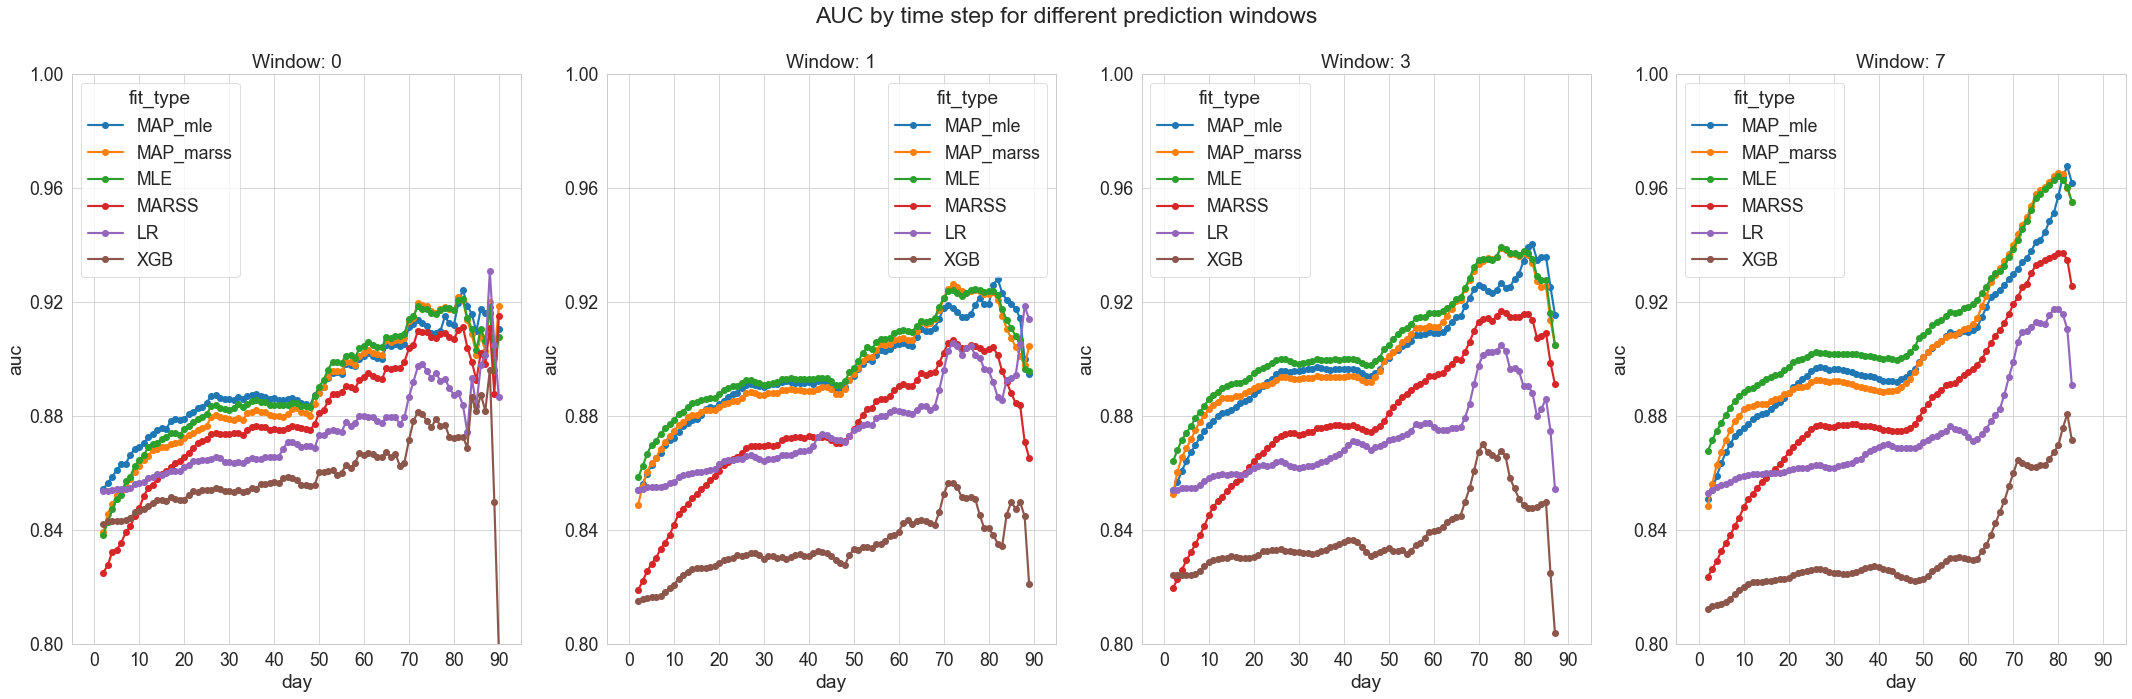

In [31]:
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2)
fig,axs = plt.subplots(1,4,figsize=(30,10))
for i,delta in enumerate(window_delta):
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='auc',hue='fit_type',ax=axs[i],native_scale=True)
    sns.pointplot(data=eval_df.query("window==@delta"),x='day',y='auc',hue='fit_type',ax=axs[i],native_scale=True)
    axs[i].set_title("Window: {}".format(str(delta)))
    axs[i].set_xlim(-5,95)
    axs[i].set_ylim(.8,1.0)
    axs[i].set_yticks(np.arange(0.8,1.04,0.04))
    axs[i].set_xticks(np.arange(0,100,10))
fig.suptitle('AUC by time step for different prediction windows')
fig.tight_layout()

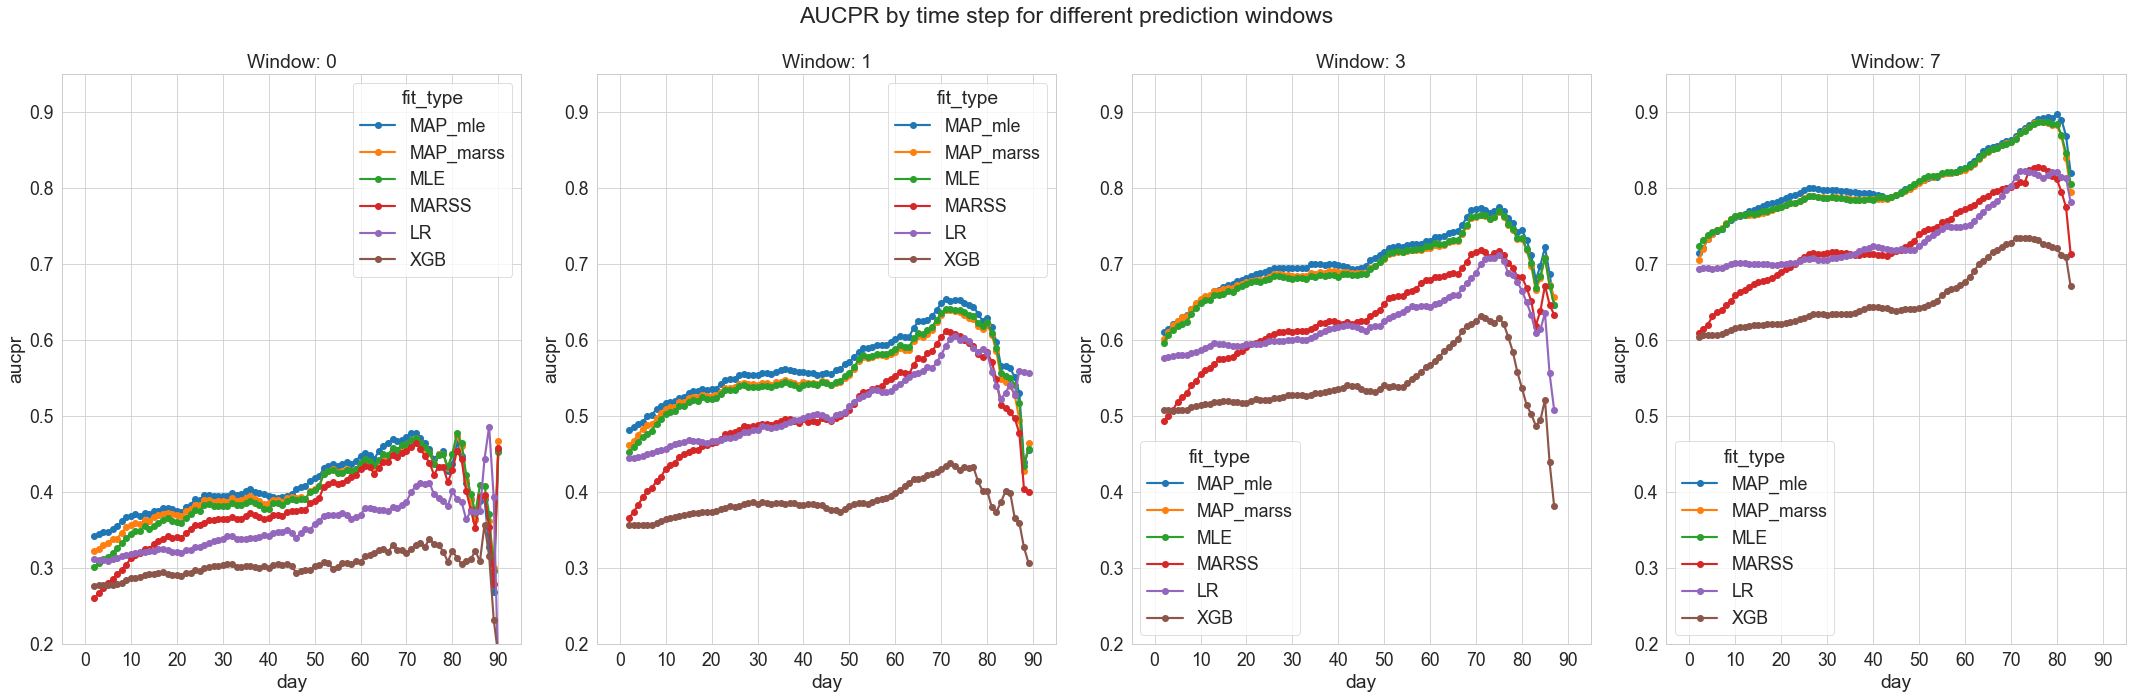

In [32]:
sns.set_style('whitegrid')
sns.set_context('paper',font_scale=2)
fig,axs = plt.subplots(1,4,figsize=(30,10))
for i,delta in enumerate(window_delta):
    #sns.pointplot(data=eval_df.query("window==@delta"),x='horizon',y='aucpr',hue='fit_type',ax=axs[i],native_scale=True)
    sns.pointplot(data=eval_df.query("window==@delta"),x='day',y='aucpr',hue='fit_type',ax=axs[i],native_scale=True)
    axs[i].set_title("Window: {}".format(str(delta)))
    axs[i].set_xlim(-5,95)
    axs[i].set_ylim(.2,0.95)
    axs[i].set_yticks(np.arange(0.2,1,0.1))
    axs[i].set_xticks(np.arange(0,100,10))
fig.suptitle('AUCPR by time step for different prediction windows')
fig.tight_layout()

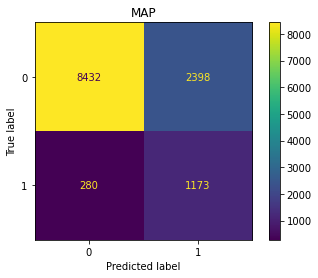

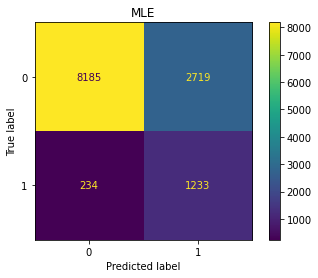

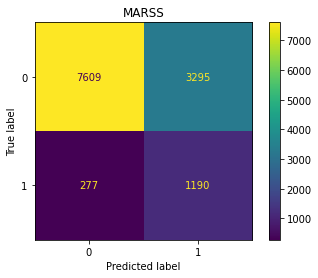

In [78]:
for fit_type in ['MAP','MLE','MARSS']:
    confusion_df = df.query("train_horizon>=2 & fit_type==@fit_type")
    pred = confusion_df.w1_pred.dropna().to_numpy()
    act = confusion_df.w1_act.dropna().to_numpy()
    fpr,tpr,thresh = roc_curve(act,pred)
    opt = np.argmax(tpr-fpr)
    cut = thresh[opt]
    pred_thresh = pred>=cut
    disp=ConfusionMatrixDisplay(confusion_matrix(act,pred_thresh))
    disp.plot()
    plt.title(fit_type)
    plt.show()